In [13]:
import pandas as pd

In [14]:
data=pd.read_csv("online_retail.csv")

In [15]:
data.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [16]:
data.shape

(541909, 9)

In [17]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   index        541909 non-null  int64  
 1   InvoiceNo    541909 non-null  str    
 2   StockCode    541909 non-null  str    
 3   Description  540455 non-null  str    
 4   Quantity     541909 non-null  int64  
 5   InvoiceDate  541909 non-null  str    
 6   UnitPrice    541909 non-null  float64
 7   CustomerID   406829 non-null  float64
 8   Country      541909 non-null  str    
dtypes: float64(2), int64(2), str(5)
memory usage: 37.2 MB


In [18]:
data.isnull().sum()

index               0
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [19]:
data=data.dropna(subset=["CustomerID"])

In [20]:
data.shape

(406829, 9)

In [21]:
data.duplicated().sum()

np.int64(0)

In [22]:
data["InvoiceDate"]=pd.to_datetime(data["InvoiceDate"])

In [67]:
# Remove returns/cancellations and invalid transactions
data = data[(data["Quantity"] > 0) & (data["UnitPrice"] > 0)]

# Calculate total purchase amount
data["totalamount"] = data["Quantity"] * data["UnitPrice"]

print("Cleaned data shape:", data.shape)
print("Negative total amounts:", (data["totalamount"] < 0).sum())


Cleaned data shape: (397884, 10)
Negative total amounts: 0


In [68]:
data[["Quantity","UnitPrice","totalamount"]].head()

,Quantity,UnitPrice,totalamount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [69]:
rfm=data.groupby("CustomerID").agg({"InvoiceDate":lambda x:(data["InvoiceDate"].max()-x.max()).days,"InvoiceNo":"nunique","totalamount":"sum"})

In [70]:
rfm.head()

,InvoiceDate,InvoiceNo,totalamount
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [71]:
rfm.columns=["recency","frequency","monetary"]

In [72]:
rfm.head()

,recency,frequency,monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [73]:
rfm.describe()

,recency,frequency,monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,307.415000
50%,50.000000,2.000000,674.485000
75%,141.000000,5.000000,1661.740000
max,373.000000,209.000000,280206.020000


In [74]:
from sklearn.preprocessing import StandardScaler 



In [75]:
scaler=StandardScaler()
rfm_scaled=scaler.fit_transform(rfm)

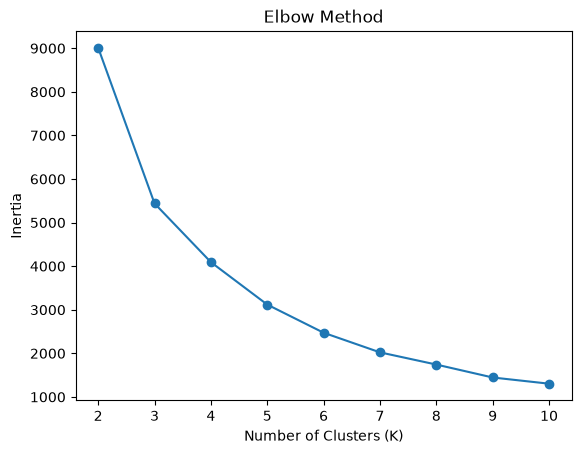

In [76]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [77]:
for k, value in zip(range(2,11), inertia):
    print(f"K: {k}, Inertia: {value}")

K: 2, Inertia: 9012.6447253454
K: 3, Inertia: 5439.304685942381
K: 4, Inertia: 4092.144305254269
K: 5, Inertia: 3118.2840089016972
K: 6, Inertia: 2472.5745137484564
K: 7, Inertia: 2022.4126705975727
K: 8, Inertia: 1742.36957675047
K: 9, Inertia: 1445.630327131001
K: 10, Inertia: 1303.3922373445594


In [78]:
Kmeans=KMeans(n_clusters=5,random_state=42,n_init=10)
rfm["cluster"]=Kmeans.fit_predict(rfm_scaled)
rfm.head()

,recency,frequency,monetary,cluster
CustomerID,,,,
12346.0,325,1,77183.60,2
12347.0,1,7,4310.00,0
12348.0,74,4,1797.24,0
12349.0,18,1,1757.55,0
12350.0,309,1,334.40,1


In [79]:
print(rfm.columns)

Index(['recency', 'frequency', 'monetary', 'cluster'], dtype='str')


In [80]:
rfm["cluster"].value_counts().sort_index()

cluster
0    3049
1    1062
2     213
3       8
4       6
Name: count, dtype: int64

In [81]:
rfm.groupby("cluster")[["recency","frequency","monetary"]].mean()

,recency,frequency,monetary
cluster,,,
0,42.952771,3.650049,1339.066659
1,247.564030,1.551789,478.107581
2,14.671362,21.286385,12831.742488
3,5.500000,120.500000,55312.686250
4,6.666667,42.833333,190863.461667


In [82]:
rfm.groupby("cluster")[["recency","frequency","monetary"]].mean().round(2)

,recency,frequency,monetary
cluster,,,
0,42.95,3.65,1339.07
1,247.56,1.55,478.11
2,14.67,21.29,12831.74
3,5.50,120.50,55312.69
4,6.67,42.83,190863.46


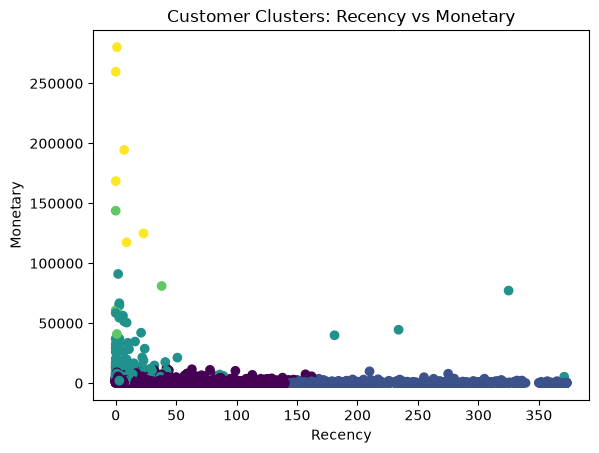

In [83]:
import matplotlib.pyplot as plt

plt.scatter(
    rfm["recency"],
    rfm["monetary"],
    c=rfm["cluster"]
)

plt.title("Customer Clusters: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.show()

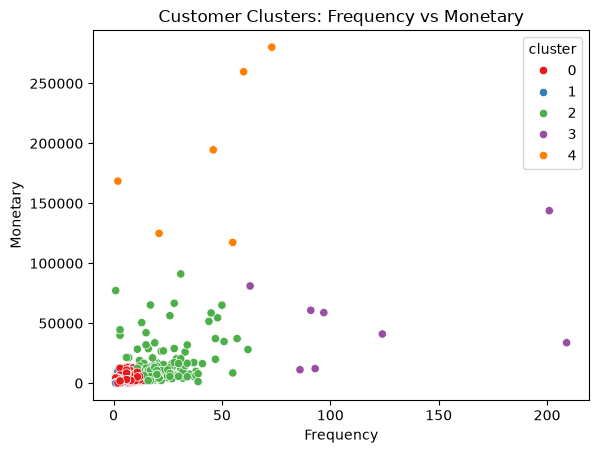

In [84]:
sns.scatterplot(
    data=rfm,
    x="frequency",
    y="monetary",
    hue="cluster",
    palette="Set1"
)

plt.title("Customer Clusters: Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.show()

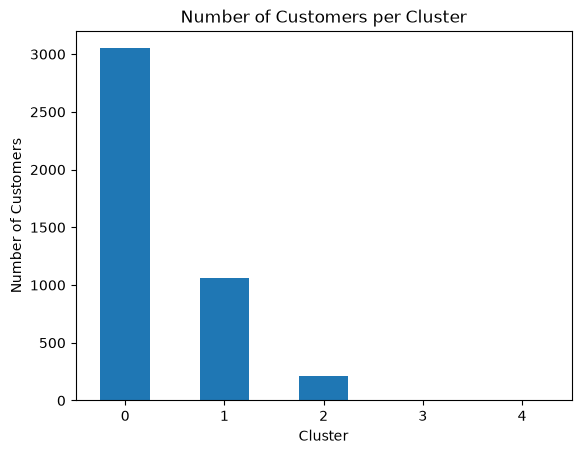

In [85]:
rfm["cluster"].value_counts().sort_index().plot(
    kind="bar",
    title="Number of Customers per Cluster"
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [86]:
cluster_summary = rfm.groupby("cluster")[["recency", "frequency", "monetary"]].mean().round(2)

cluster_summary["customer_count"] = rfm["cluster"].value_counts().sort_index()

cluster_summary

,recency,frequency,monetary,customer_count
cluster,,,,
0,42.95,3.65,1339.07,3049
1,247.56,1.55,478.11,1062
2,14.67,21.29,12831.74,213
3,5.50,120.50,55312.69,8
4,6.67,42.83,190863.46,6


In [87]:
marketing_actions = {
    0: "Occasional customers — encourage engagement with personalized offers and recommendations.",
    1: "At-risk customers — use reactivation emails, discounts, and reminders.",
    2: "VIP high-value customers — provide loyalty rewards, exclusive offers, and personalized service.",
    3: "Highly frequent customers — strengthen loyalty with rewards, bundles, and cross-selling.",
    4: "Regular customers — encourage repeat purchases with targeted promotions and loyalty benefits."
}

for cluster, action in marketing_actions.items():
    print(f"Cluster {cluster}: {action}")

Cluster 0: Occasional customers — encourage engagement with personalized offers and recommendations.
Cluster 1: At-risk customers — use reactivation emails, discounts, and reminders.
Cluster 2: VIP high-value customers — provide loyalty rewards, exclusive offers, and personalized service.
Cluster 3: Highly frequent customers — strengthen loyalty with rewards, bundles, and cross-selling.
Cluster 4: Regular customers — encourage repeat purchases with targeted promotions and loyalty benefits.


In [90]:
# Additional Descriptive Statistics

# Average value of a single transaction
average_purchase_value = data["totalamount"].mean()

# Average number of purchases per customer
average_purchase_frequency = rfm["frequency"].mean()

# Historical customer lifetime value proxy
customer_lifetime_value = rfm["monetary"].mean()

print("Average Purchase Value:", round(average_purchase_value, 2))
print("Average Purchase Frequency:", round(average_purchase_frequency, 2))
print("Average Customer Lifetime Value:", round(customer_lifetime_value, 2))

# Check for inconsistent values
print("\nNegative Recency values:", (rfm["recency"] < 0).sum())
print("Negative Frequency values:", (rfm["frequency"] < 0).sum())
print("Negative Monetary values:", (rfm["monetary"] < 0).sum())

Average Purchase Value: 22.4
Average Purchase Frequency: 4.27
Average Customer Lifetime Value: 2054.27

Negative Recency values: 0
Negative Frequency values: 0
Negative Monetary values: 0
